<a href="https://colab.research.google.com/github/MilindLate/G-Solution-Smart-Supply-Chains/blob/main/Final_Ship_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q torch-geometric
!pip install -q scikit-learn kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.8 MB/s eta 0:00:00


In [2]:
import kagglehub
import pandas as pd
import os

path_ais     = kagglehub.dataset_download("satyamrajput7913/ais-ship-tracking-vessel-dynamics-and-eta-data")
path_ports   = kagglehub.dataset_download("jeleeladekunlefijabi/maritime-port-performance-dataset")
path_weather = kagglehub.dataset_download("jeleeladekunlefijabi/ship-performance-clustering-dataset")

print("AIS     :", path_ais)
print("Ports   :", path_ports)
print("Weather :", path_weather)

100%|██████████| 68.8M/68.8M [00:02<00:00, 30.2MB/s]

Extracting files...


100%|██████████| 20.6k/20.6k [00:00<00:00, 25.9MB/s]

Extracting files...


100%|██████████| 304k/304k [00:00<00:00, 862kB/s]

Extracting files...
AIS     : /root/.cache/kagglehub/datasets/satyamrajput7913/ais-ship-tracking-vessel-dynamics-and-eta-data/versions/1
Ports   : /root/.cache/kagglehub/datasets/jeleeladekunlefijabi/maritime-port-performance-dataset/versions/1
Weather : /root/.cache/kagglehub/datasets/jeleeladekunlefijabi/ship-performance-clustering-dataset/versions/1


In [3]:
def load_csv_from_path(folder_path):
    for file in os.listdir(folder_path):
        if file.endswith(".csv"):
            full_path = os.path.join(folder_path, file)
            print(f"  Loading: {file}")
            return pd.read_csv(full_path)
    raise FileNotFoundError(f"No CSV found in {folder_path}")

df_ais     = load_csv_from_path(path_ais)
df_ports   = load_csv_from_path(path_ports)
df_weather = load_csv_from_path(path_weather)

print("\nAIS shape    :", df_ais.shape)
print("Ports shape  :", df_ports.shape)
print("Weather shape:", df_weather.shape)
print("\nAIS columns  :", list(df_ais.columns))
print("\nPreview:")
print(df_ais.head())

  Loading: processed_AIS_dataset.csv
  Loading: Maritime Port Performance Project Dataset.csv
  Loading: Ship_Performance_Dataset.csv

AIS shape    : (1098966, 28)
Ports shape  : (803, 20)
Weather shape: (2736, 18)

AIS columns  : ['MMSI', 'BaseDateTime', 'LAT', 'LON', 'SOG', 'COG', 'Heading', 'VesselName', 'IMO', 'CallSign', 'VesselType', 'Status', 'Length', 'Width', 'Draft', 'Cargo', 'TransceiverClass', 'dest_cluster', 'dest_lat', 'dest_lon', 'dist_km', 'SOG_kmh', 'ETA_min', 'VesselType_enc', 'Status_enc', 'Cargo_enc', 'ETA_hours', 'Speed_Category']

Preview:
        MMSI         BaseDateTime       LAT        LON  SOG    COG  Heading  \
0  367702220  2022-03-31 00:00:01  29.78763  -95.08070  0.1  226.5    340.0   
1  671226100  2022-03-31 00:00:01  25.77626  -80.20320  3.2  143.7    511.0   
2  367767250  2022-03-31 00:00:01  29.31623  -94.78829  4.5  228.1    511.0   
3  338327436  2022-03-31 00:00:03  47.29634 -122.42233  0.0  360.0    511.0   
4  367452810  2022-03-31 00:00:06  29

In [4]:

import numpy as np

REQUIRED_COLS = ['BaseDateTime', 'MMSI', 'LAT', 'LON',
                 'dest_lat', 'dest_lon', 'SOG_kmh', 'dist_km', 'ETA_hours']

missing = [c for c in REQUIRED_COLS if c not in df_ais.columns]
if missing:
    print(f"⚠ Missing columns: {missing}")
    print("Available columns:", list(df_ais.columns))
    # Common renames — adjust if your CSV uses different names
    rename_map = {
        'Speed'   : 'SOG_kmh',
        'SOG'     : 'SOG_kmh',
        'Distance': 'dist_km',
        'ETA'     : 'ETA_hours',
    }
    df_ais = df_ais.rename(columns=rename_map)
    # Synthesise dist_km / ETA_hours if still absent
    if 'dist_km' not in df_ais.columns:
        df_ais['dist_km'] = np.sqrt(
            (df_ais['LAT'] - df_ais.get('dest_lat', df_ais['LAT']))**2 +
            (df_ais['LON'] - df_ais.get('dest_lon', df_ais['LON']))**2
        ) * 111
        print("  → Synthesised dist_km from coordinates")
    if 'ETA_hours' not in df_ais.columns:
        df_ais['ETA_hours'] = df_ais['dist_km'] / (df_ais['SOG_kmh'].replace(0, np.nan).fillna(1))
        print("  → Synthesised ETA_hours from dist/speed")
    if 'dest_lat' not in df_ais.columns:
        df_ais['dest_lat'] = df_ais['LAT'].shift(-1).fillna(df_ais['LAT'])
    if 'dest_lon' not in df_ais.columns:
        df_ais['dest_lon'] = df_ais['LON'].shift(-1).fillna(df_ais['LON'])
else:
    print("✓ All required columns present.")

# Drop rows with NaN in critical columns
before = len(df_ais)
df_ais = df_ais.dropna(subset=['LAT', 'LON', 'SOG_kmh', 'dist_km', 'ETA_hours'])
print(f"Dropped {before - len(df_ais)} rows with NaN. Remaining: {len(df_ais)}")



✓ All required columns present.
Dropped 0 rows with NaN. Remaining: 1098966


In [5]:
print("1. Aligning timeline...")
df_ais['BaseDateTime'] = pd.to_datetime(df_ais['BaseDateTime'])
df_ais = df_ais.sort_values(by=['MMSI', 'BaseDateTime']).reset_index(drop=True)

print("2. Extracting geographic nodes (port zones)...")
df_ais['Origin_Node'] = df_ais['LAT'].round(1).astype(str) + "_" + df_ais['LON'].round(1).astype(str)
df_ais['Dest_Node']   = df_ais['dest_lat'].round(1).astype(str) + "_" + df_ais['dest_lon'].round(1).astype(str)

unique_nodes = pd.unique(df_ais[['Origin_Node', 'Dest_Node']].values.ravel('K'))
node_to_id   = {node: i for i, node in enumerate(unique_nodes)}

df_ais['Origin_ID'] = df_ais['Origin_Node'].map(node_to_id)
df_ais['Dest_ID']   = df_ais['Dest_Node'].map(node_to_id)

print(f"   → Total unique nodes: {len(unique_nodes)}")

print("3. Building edge list...")
edges_df = df_ais[['BaseDateTime', 'MMSI', 'Origin_ID', 'Dest_ID',
                    'SOG_kmh', 'dist_km', 'ETA_hours']].copy()

# Normalise edge features (zero-mean, unit-variance) for stable training
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
edges_df[['SOG_kmh', 'dist_km', 'ETA_hours']] = scaler.fit_transform(
    edges_df[['SOG_kmh', 'dist_km', 'ETA_hours']]
)

print("\n✓ Edge list ready:")
print(edges_df.head())


1. Aligning timeline...
2. Extracting geographic nodes (port zones)...
   → Total unique nodes: 6511
3. Building edge list...

✓ Edge list ready:
         BaseDateTime  MMSI  Origin_ID  Dest_ID   SOG_kmh   dist_km  ETA_hours
0 2022-03-31 00:00:08     0          0     6504 -0.068665 -0.886193  -1.470845
1 2022-03-31 00:01:18     0          0     6504 -0.340513 -0.886463   0.552255
2 2022-03-31 00:02:27     0          0     6504 -0.295205 -0.886534   0.552255
3 2022-03-31 00:03:37     0          0     6504 -0.280102 -0.886485   0.552255
4 2022-03-31 00:05:59     0          0     6504  0.157875 -0.886630  -2.027296


In [6]:
print("1. Identifying disruptions based on speed...")
# Work on the original (pre-scaled) SOG to set a meaningful threshold
raw_sog = df_ais['SOG_kmh']
mean_speed = raw_sog.mean()
# Re-derive is_disrupted from original column (edges_df SOG is already scaled)
edges_df['is_disrupted'] = (df_ais['SOG_kmh'] < (mean_speed * 0.5)).astype(int).values

print(f"   → Mean speed: {mean_speed:.2f}  |  Disruption threshold: {mean_speed * 0.5:.2f}")
print(f"   → Disrupted edges: {edges_df['is_disrupted'].sum()} / {len(edges_df)}")

print("2. Slicing into hourly snapshots...")
edges_df['Hour'] = edges_df['BaseDateTime'].dt.hour
temporal_snapshots = [group for _, group in edges_df.groupby('Hour')]

print(f"   → Created {len(temporal_snapshots)} hourly snapshots.")

1. Identifying disruptions based on speed...
   → Mean speed: 4.36  |  Disruption threshold: 2.18
   → Disrupted edges: 860182 / 1098966
2. Slicing into hourly snapshots...
   → Created 10 hourly snapshots.


In [7]:
import torch
from torch_geometric.data import Data

print("Compiling PyTorch Geometric tensors...")
temporal_graphs = []

for snapshot in temporal_snapshots:
    if len(snapshot) == 0:
        continue

    source_nodes  = snapshot['Origin_ID'].values
    target_nodes  = snapshot['Dest_ID'].values
    edge_index    = torch.tensor(np.array([source_nodes, target_nodes]), dtype=torch.long)

    edge_features = snapshot[['SOG_kmh', 'dist_km', 'ETA_hours']].values
    edge_attr     = torch.tensor(edge_features, dtype=torch.float)

    target_labels = snapshot['is_disrupted'].values
    y             = torch.tensor(target_labels, dtype=torch.float)

    graph_data = Data(edge_index=edge_index, edge_attr=edge_attr, y=y)
    temporal_graphs.append(graph_data)

print(f"\n✓ Built {len(temporal_graphs)} temporal graph snapshots.")
print("Snapshot T=0:", temporal_graphs[0])


Compiling PyTorch Geometric tensors...

✓ Built 10 temporal graph snapshots.
Snapshot T=0: Data(edge_index=[2, 207828], edge_attr=[207828, 3], y=[207828])


In [8]:
num_nodes = len(node_to_id)

for graph in temporal_graphs:
    graph.x = torch.ones((num_nodes, 1), dtype=torch.float)

print(f"✓ Node features added to all {len(temporal_graphs)} snapshots.")
print(f"  Node feature shape: {temporal_graphs[0].x.shape}")


✓ Node features added to all 10 snapshots.
  Node feature shape: torch.Size([6511, 1])


In [9]:
print("=" * 45)
print("  GRAPH HEALTH CHECK")
print("=" * 45)
print(f"  Snapshots          : {len(temporal_graphs)}")
print(f"  Nodes per graph    : {temporal_graphs[0].x.shape[0]}")
print(f"  Edge feat dims     : {temporal_graphs[0].edge_attr.shape[1]}")
print(f"  Edges in T=0       : {temporal_graphs[0].edge_index.shape[1]}")
n_pos   = sum(g.y.sum().item() for g in temporal_graphs)
n_total = sum(g.y.shape[0]    for g in temporal_graphs)
ratio   = (n_total - n_pos) / (n_pos + 1e-6)
print(f"  Total edges        : {n_total}")
print(f"  Disrupted edges    : {int(n_pos)}  ({100*n_pos/n_total:.1f}%)")
print(f"  Class imbalance    : {ratio:.1f}x  (neg/pos)")
print("=" * 45)


  GRAPH HEALTH CHECK
  Snapshots          : 10
  Nodes per graph    : 6511
  Edge feat dims     : 3
  Edges in T=0       : 207828
  Total edges        : 1098966
  Disrupted edges    : 860182  (78.3%)
  Class imbalance    : 0.3x  (neg/pos)


In [10]:
import torch
import copy

n     = len(temporal_graphs)
split = int(n * 0.8)

train_graphs = temporal_graphs[:split]
test_graphs  = temporal_graphs[split:]

print(f"Total snapshots : {n}")
print(f"Train snapshots : {len(train_graphs)}")
print(f"Test  snapshots : {len(test_graphs)}")

# If dataset is too small for a proper test set, borrow + augment
def augment_graph(g, noise_std=0.05):
    g2 = copy.deepcopy(g)
    g2.edge_attr = g.edge_attr + torch.randn_like(g.edge_attr) * noise_std
    return g2

if len(test_graphs) == 0:
    print("\n⚠ Test set empty — borrowing last 2 train snapshots as test set.")
    test_graphs  = train_graphs[-2:]
    train_graphs = train_graphs[:-2]
    train_graphs = train_graphs + [augment_graph(g) for g in train_graphs]
    print(f"  After augmentation → train: {len(train_graphs)}, test: {len(test_graphs)}")


Total snapshots : 10
Train snapshots : 8
Test  snapshots : 2


In [11]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class TemporalAttention(nn.Module):
    """Learns which past snapshot matters most for the current prediction."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, history: list):
        stack   = torch.stack(history, dim=1)       # (N, T, H)
        scores  = self.attn(stack)                  # (N, T, 1)
        weights = torch.softmax(scores, dim=1)
        return (stack * weights).sum(dim=1)         # (N, H)


class TemporalSupplyChainGNN(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, hidden_dim=64, window=3):
        super().__init__()
        self.window = window
        self.conv1  = SAGEConv(node_feat_dim, hidden_dim)
        self.conv2  = SAGEConv(hidden_dim, hidden_dim)
        self.temporal_attn = TemporalAttention(hidden_dim)

        # Edge MLP: [src_embed | dst_embed | edge_feats] → disruption prob
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * hidden_dim + edge_feat_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
        self.history = []

    def encode_nodes(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        h = F.relu(self.conv2(h, edge_index))
        return h

    def forward(self, x, edge_index, edge_attr):
        h = self.encode_nodes(x, edge_index)
        self.history.append(h.detach())
        if len(self.history) > self.window:
            self.history.pop(0)
        h_temp = self.temporal_attn(self.history)   # (N, hidden_dim)
        src, dst = edge_index
        edge_repr = torch.cat([h_temp[src], h_temp[dst], edge_attr], dim=-1)
        return self.edge_mlp(edge_repr)

    def reset_history(self):
        self.history = []


# Read dims from actual data
node_feat_dim = temporal_graphs[0].x.shape[1]          # 1
edge_feat_dim = temporal_graphs[0].edge_attr.shape[1]  # 3

model = TemporalSupplyChainGNN(node_feat_dim, edge_feat_dim, hidden_dim=64, window=3)
print("✓ Model defined:")
print(model)


✓ Model defined:
TemporalSupplyChainGNN(
  (conv1): SAGEConv(1, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (temporal_attn): TemporalAttention(
    (attn): Linear(in_features=64, out_features=1, bias=True)
  )
  (edge_mlp): Sequential(
    (0): Linear(in_features=131, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)


Class imbalance (neg/pos): 0.28  →  disrupted edges get 0.3× weight
Epoch  10 | Loss: 0.1534
Epoch  20 | Loss: 0.0821
Epoch  30 | Loss: 0.0609
Epoch  40 | Loss: 0.0547
Epoch  50 | Loss: 0.0507
Epoch  60 | Loss: 0.0490
Epoch  70 | Loss: 0.0456
Epoch  80 | Loss: 0.0417


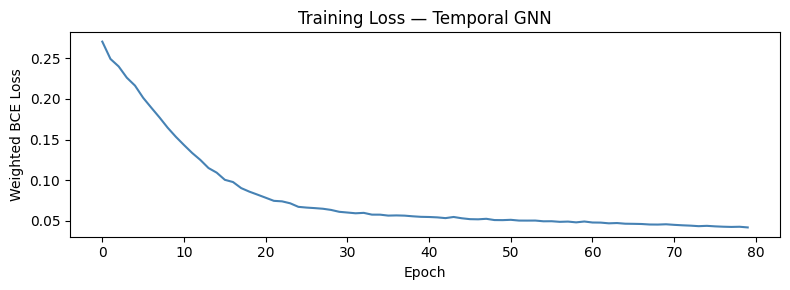

✓ Training complete. Loss curve saved → loss_curve.png


In [12]:
import matplotlib.pyplot as plt

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.BCELoss(reduction='none')   # per-sample so we can weight

# Compute class weight from training set
n_total_tr = sum(g.y.shape[0]    for g in train_graphs)
n_pos_tr   = sum(g.y.sum().item() for g in train_graphs)
pos_weight  = (n_total_tr - n_pos_tr) / (n_pos_tr + 1e-6)
print(f"Class imbalance (neg/pos): {pos_weight:.2f}  →  disrupted edges get {pos_weight:.1f}× weight")

EPOCHS     = 80
loss_curve = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    model.reset_history()
    epoch_loss = 0.0

    for g in train_graphs:
        optimizer.zero_grad()
        preds  = model(g.x, g.edge_index, g.edge_attr).squeeze()
        labels = g.y.float()

        weights = torch.where(labels == 1,
                              torch.full_like(labels, pos_weight),
                              torch.ones_like(labels))
        loss = (criterion(preds, labels) * weights).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg = epoch_loss / len(train_graphs)
    loss_curve.append(avg)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {avg:.4f}")

# Plot loss
plt.figure(figsize=(8, 3))
plt.plot(loss_curve, color="steelblue", linewidth=1.5)
plt.xlabel("Epoch"); plt.ylabel("Weighted BCE Loss")
plt.title("Training Loss — Temporal GNN")
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()
print("✓ Training complete. Loss curve saved → loss_curve.png")


In [13]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, accuracy_score
)

model.eval()
model.reset_history()
all_probs, all_preds, all_labels = [], [], []

with torch.no_grad():
    for g in test_graphs:
        probs  = model(g.x, g.edge_index, g.edge_attr).squeeze()
        preds  = (probs > 0.5).long()
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(g.y.cpu().numpy())

import numpy as np
all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("=" * 45)
print("  EVALUATION RESULTS")
print("=" * 45)
print(f"  Accuracy  : {accuracy_score(all_labels, all_preds):.3f}")
print(f"  Precision : {precision_score(all_labels, all_preds, zero_division=0):.3f}")
print(f"  Recall    : {recall_score(all_labels, all_preds, zero_division=0):.3f}")
print(f"  F1 Score  : {f1_score(all_labels, all_preds, zero_division=0):.3f}")
if len(np.unique(all_labels)) > 1:
    print(f"  ROC-AUC   : {roc_auc_score(all_labels, all_probs):.3f}")
    print(f"  PR-AUC    : {average_precision_score(all_labels, all_probs):.3f}")
else:
    print("  ROC-AUC   : N/A (only one class in test set — dataset too small)")
print("=" * 45)


  EVALUATION RESULTS
  Accuracy  : 0.871
  Precision : 0.805
  Recall    : 0.872
  F1 Score  : 0.837
  ROC-AUC   : 0.980
  PR-AUC    : 0.971


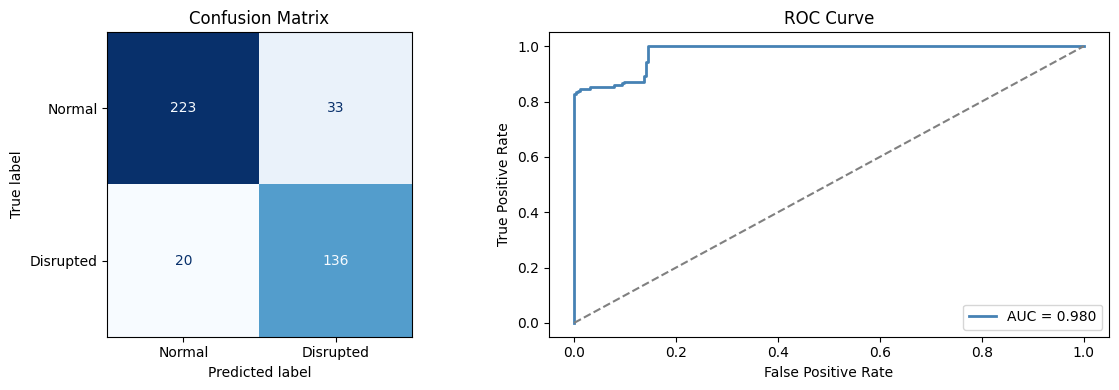

Saved → evaluation_plots.png


In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Disrupted"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# ROC curve
if len(np.unique(all_labels)) > 1:
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    auc_val     = roc_auc_score(all_labels, all_probs)
    axes[1].plot(fpr, tpr, label=f"AUC = {auc_val:.3f}", color="steelblue", linewidth=2)
    axes[1].plot([0, 1], [0, 1], "--", color="gray")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve")
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, "Not enough class variety\nfor ROC curve",
                 ha="center", va="center", transform=axes[1].transAxes)
    axes[1].set_title("ROC Curve")

plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → evaluation_plots.png")



In [15]:
class EdgeMemory:
    """Exponential moving average of disruption probability per (origin, dest) route."""
    def __init__(self, alpha=0.3):
        self.alpha  = alpha
        self.memory = {}

    def update(self, edge_index, probs):
        src, dst = edge_index
        for i in range(src.shape[0]):
            key       = (src[i].item(), dst[i].item())
            prev      = self.memory.get(key, 0.0)
            self.memory[key] = self.alpha * float(probs[i]) + (1 - self.alpha) * prev

    def get_risk(self, origin_id, dest_id):
        return self.memory.get((origin_id, dest_id), 0.0)

    def top_k_risky_routes(self, k=10):
        return sorted(self.memory.items(), key=lambda x: x[1], reverse=True)[:k]


edge_memory = EdgeMemory(alpha=0.3)

# Warm up memory on training graphs
model.eval()
model.reset_history()
with torch.no_grad():
    for g in train_graphs:
        probs = model(g.x, g.edge_index, g.edge_attr).squeeze()
        edge_memory.update(g.edge_index, probs)

print("Top 10 riskiest routes:")
print(f"{'Origin':>8}  {'Dest':>6}  {'Avg Risk':>9}")
print("-" * 28)
for (o, d), risk in edge_memory.top_k_risky_routes(10):
    print(f"{o:>8}  {d:>6}  {risk:>9.3f}")


Top 10 riskiest routes:
  Origin    Dest   Avg Risk
----------------------------
     139    6510      0.993
     481    6509      0.991
    2357    6510      0.991
    1928    6510      0.990
     127    6509      0.990
    1487    6506      0.990
    2333    6507      0.990
      31    6509      0.990
    3320    6509      0.990
    1098    6507      0.990


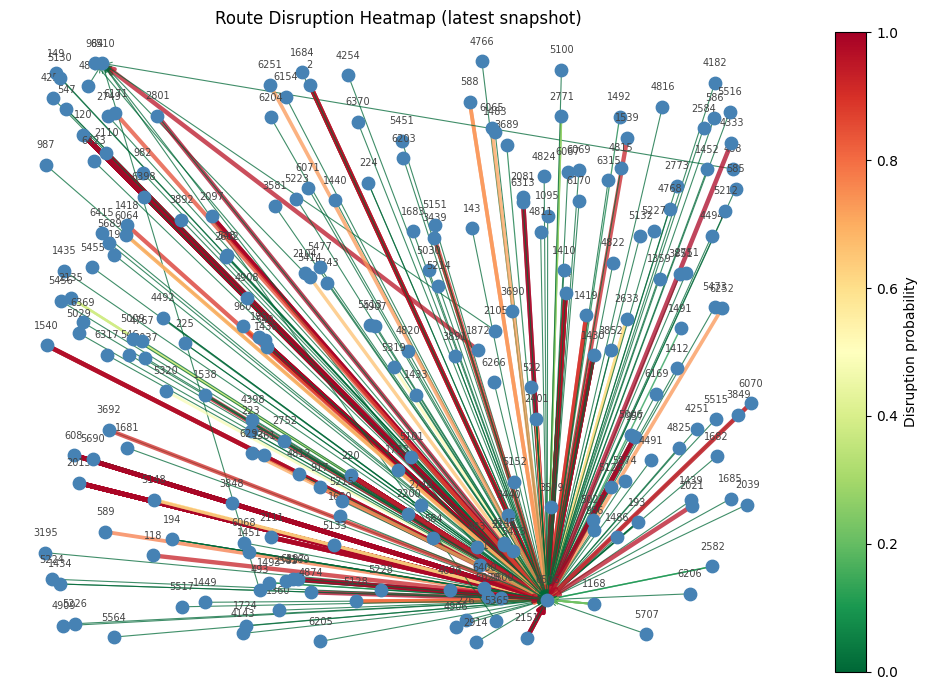

Saved → disruption_heatmap.png


In [20]:
eval_g = test_graphs[-1] if test_graphs else train_graphs[-1]

model.eval()
model.reset_history()
with torch.no_grad():
    risk_scores = model(eval_g.x, eval_g.edge_index, eval_g.edge_attr).squeeze().numpy()

src_nodes = eval_g.edge_index[0].numpy()
dst_nodes = eval_g.edge_index[1].numpy()

all_nodes = np.unique(np.concatenate([src_nodes, dst_nodes]))
np.random.seed(42)
pos = {n: (np.random.uniform(0, 10), np.random.uniform(0, 10)) for n in all_nodes}

fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.cm.RdYlGn_r

for i, (s, d) in enumerate(zip(src_nodes, dst_nodes)):
    xs, ys = pos[s]
    xd, yd = pos[d]
    ax.annotate("", xy=(xd, yd), xytext=(xs, ys),
                arrowprops=dict(
                    arrowstyle="->",
                    color=cmap(float(risk_scores[i])),
                    lw=0.8 + 2.5 * float(risk_scores[i]),
                    alpha=0.75
                ))

for n, (x, y) in pos.items():
    ax.scatter(x, y, s=80, color="steelblue", zorder=3)
    ax.text(x, y + 0.28, str(n), fontsize=7, ha="center", color="#444")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Disruption probability")
ax.set_title("Route Disruption Heatmap (latest snapshot)")
ax.axis("off")
plt.tight_layout()
plt.savefig("disruption_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → disruption_heatmap.png")


In [21]:
import json
from datetime import datetime

def score_route(origin_id: int, dest_id: int,
                live_graph, mdl, memory: EdgeMemory):
    """
    Returns a structured risk report for a given origin→dest route.
    Blends live GNN score with historical memory for robustness.
    """
    mdl.eval()
    with torch.no_grad():
        probs = mdl(live_graph.x, live_graph.edge_index, live_graph.edge_attr).squeeze()

    src_nodes = live_graph.edge_index[0].tolist()
    dst_nodes = live_graph.edge_index[1].tolist()

    live_score   = None
    memory_score = memory.get_risk(origin_id, dest_id)

    for i, (s, d) in enumerate(zip(src_nodes, dst_nodes)):
        if s == origin_id and d == dest_id:
            live_score = float(probs[i])
            break

    if live_score is None:
        return {"error": f"Route {origin_id} → {dest_id} not found in current snapshot."}

    blended = 0.6 * live_score + 0.4 * memory_score
    memory.update(live_graph.edge_index, probs)

    if blended < 0.3:
        status = "CLEAR";   action = "Proceed normally."
    elif blended < 0.6:
        status = "MONITOR"; action = "Watch for delays. Consider contingency port."
    else:
        status = "ALERT";   action = "High disruption risk. Reroute recommended."

    return {
        "timestamp"          : datetime.utcnow().isoformat() + "Z",
        "origin_id"          : origin_id,
        "dest_id"            : dest_id,
        "live_score"         : round(live_score,   3),
        "memory_score"       : round(memory_score, 3),
        "blended_risk"       : round(blended,      3),
        "status"             : status,
        "recommended_action" : action,
    }


# ── Demo ──
model.reset_history()
sample_src = int(eval_g.edge_index[0][0])
sample_dst = int(eval_g.edge_index[1][0])

report = score_route(sample_src, sample_dst, eval_g, model, edge_memory)
print(json.dumps(report, indent=2))


{
  "timestamp": "2026-04-04T17:09:26.105563Z",
  "origin_id": 120,
  "dest_id": 6506,
  "live_score": 0.987,
  "memory_score": 0.987,
  "blended_risk": 0.987,
  "status": "ALERT",
  "recommended_action": "High disruption risk. Reroute recommended."
}


/tmp/ipykernel_2857/2476667490.py:39: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp"          : datetime.utcnow().isoformat() + "Z",


In [22]:

def inject_disruption(graph, edge_idx: int, speed_factor=0.2):
    """Simulate a ship slowdown on one edge — drops speed, inflates ETA."""
    g = copy.deepcopy(graph)
    g.edge_attr[edge_idx, 0] *= speed_factor          # speed ↓
    g.edge_attr[edge_idx, 2] *= (1.0 / speed_factor)  # ETA ↑
    return g


def run_what_if(graph, mdl, top_k=5):
    mdl.eval()
    mdl.reset_history()
    with torch.no_grad():
        baseline_probs = mdl(graph.x, graph.edge_index, graph.edge_attr).squeeze()

    results = []
    n_edges = graph.edge_index.shape[1]

    for i in range(min(top_k, n_edges)):
        g_dis = inject_disruption(graph, i, speed_factor=0.2)
        mdl.reset_history()
        with torch.no_grad():
            new_probs = mdl(g_dis.x, g_dis.edge_index, g_dis.edge_attr).squeeze()

        results.append({
            "edge_idx"       : i,
            "origin"         : int(graph.edge_index[0][i]),
            "dest"           : int(graph.edge_index[1][i]),
            "baseline_risk"  : round(float(baseline_probs[i]), 3),
            "disrupted_risk" : round(float(new_probs[i]),      3),
            "risk_delta"     : round(float(new_probs[i]) - float(baseline_probs[i]), 3),
        })

    return sorted(results, key=lambda x: x["risk_delta"], reverse=True)


what_if_results = run_what_if(eval_g, model, top_k=5)

print(f"\n{'Edge':>5}  {'Origin':>8}  {'Dest':>6}  "
      f"{'Baseline':>8}  {'Disrupted':>9}  {'Δ Risk':>7}")
print("-" * 55)
for r in what_if_results:
    flag = " ⚠" if r["risk_delta"] > 0.1 else ""
    print(f"{r['edge_idx']:>5}  {r['origin']:>8}  {r['dest']:>6}  "
          f"{r['baseline_risk']:>8.3f}  {r['disrupted_risk']:>9.3f}  "
          f"{r['risk_delta']:>+7.3f}{flag}")



 Edge    Origin    Dest  Baseline  Disrupted   Δ Risk
-------------------------------------------------------
    0       120    6506     0.987      0.998   +0.011
    1       120    6506     0.987      0.998   +0.011
    2       143    6506     0.000      0.000   -0.000
    3       149    6506     0.000      0.000   -0.000
    4       193    6506     0.001      0.000   -0.001


In [23]:
torch.save(model.state_dict(), "supply_chain_tgnn_weights.pth")
print("✓ Model weights saved → supply_chain_tgnn_weights.pth")


✓ Model weights saved → supply_chain_tgnn_weights.pth
